## House Price – Data Preparation & Feature Engineering

### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer


RANDOM_STATE = 83
# setting the seed
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = 'SalePrice'
DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 81)
pd.set_option("display.width", 150)
sns.set_style('whitegrid')

### Load Data

In [2]:
url = 'https://raw.githubusercontent.com/errodd/Houses-Prices---ML-/refs/heads/EDA/data/houses_prices.csv'
df = pd.read_csv(url)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


### No Missing Target

In [3]:
df = df[df["SalePrice"].notna()]
# Confirm No Missing Target
df["SalePrice"].isnull().sum()

np.int64(0)

# Target Variable Transformation

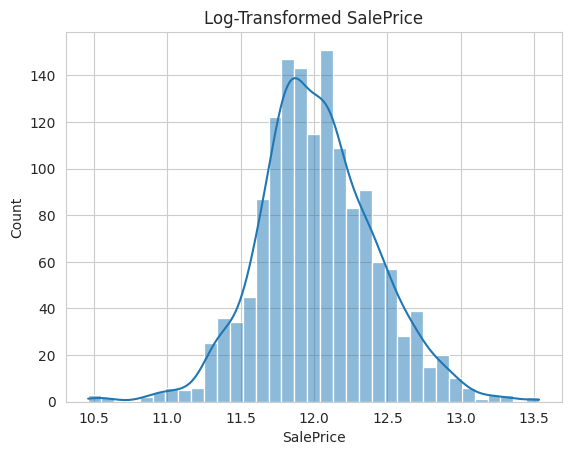

In [4]:
df["SalePrice"] = np.log1p(df["SalePrice"])

sns.histplot(df["SalePrice"], kde=True)
plt.title("Log-Transformed SalePrice")
plt.show()

After an exhaustive analysis in the Exploratory Data Analysis (EDA), we demonstrated that these are the columns that should be included in the model

These features were selected based on their statistical significance, correlation with the target variable, and their contribution to the model's predictive performance during the EDA phase.

In [5]:

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220


### **Advanced Feature Engineering Summary**

---

#### **1. Bathroom Consolidation (`TotalBath`)**
* **Action:** Combines 4 bathroom types into one weighted metric.
* **Reason:** **Simplifies Capacity.** It captures the total "utility" of bathrooms (giving half-baths 0.5 weight) in a single, high-correlation feature.

#### **2. Outdoor Space Consolidation (`TotalOutdoorSF`)**
* **Action:** Sums all porches, decks, and enclosed outdoor areas.
* **Reason:** **Reduces Sparsity.** Many individual porch columns contain mostly zeros; combining them creates a more meaningful "Total Exterior Living" variable.

#### **3. Total House Surface (`TotalSF`)**
* **Action:** Sums Basement, 1st Floor, and 2nd Floor square footage.
* **Reason:** **Creates a Mega-Predictor.** It represents the entire finished physical footprint of the property, often becoming the strongest predictor for house price.

#### **4. Room Density (`AvgRoomSize`)**
* **Action:** Divides total living area by total rooms.
* **Reason:** **Captures Spaciousness.** It distinguishes between a large house with many tiny rooms versus one with fewer, larger, luxury-feeling spaces.

#### **5. Logarithmic Transformation (`Log_`)**
* **Action:** Applies `np.log1p` to skewed area metrics.
* **Reason:** **Normalizes Distribution.** House sizes are usually "right-skewed" (a few massive houses). The log transform pulls in outliers, making the relationship with price more linear and stable for the model.

In [6]:
def advanced_feature_engineering(df):
    # --- 1. BATHROOMS (Consolidation) ---
    # Creating a single metric for total bathing capacity
    df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) +
                       df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

    # --- 2. OUTDOOR SPACE (Consolidation) ---
    # Combining all porch/deck types into one 'OutdoorSF'
    porch_cols = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'WoodDeckSF']
    df['TotalOutdoorSF'] = df[porch_cols].sum(axis=1)

    # --- 3. TOTAL HOUSE SURFACE (The "Mega-Predictor") ---
    # Total finished square footage (Basement + Above Ground)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # --- 4. ROOM DENSITY ---
    # Average size per room (Total living area / total rooms)
    # This identifies if rooms are spacious or cramped
    df['AvgRoomSize'] = df['GrLivArea'] / df['TotRmsAbvGrd']

    # --- 5. LOGARITHMIC TRANSFORMATION ---
    # House prices and area metrics are usually right-skewed.
    # Log transformation (log1p = log(1+x)) normalizes the distribution.
    skewed_features = ['TotalSF', 'GrLivArea', 'TotalOutdoorSF', '1stFlrSF']

    for col in skewed_features:
        if col in df.columns:
            # We use log1p to avoid issues with 0 values (especially in OutdoorSF)
            df[f'Log_{col}'] = np.log1p(df[col])

    return df
df = advanced_feature_engineering(df)

In [7]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBath,TotalOutdoorSF,TotalSF,AvgRoomSize,Log_TotalSF,Log_GrLivArea,Log_TotalOutdoorSF,Log_1stFlrSF
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,...,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699,3.5,61,2566.0,213.750000,7.850493,7.444833,4.127134,6.753438
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,...,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016,2.5,298,2524.0,210.333333,7.833996,7.141245,5.700444,7.141245
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,...,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171,3.5,42,2706.0,297.666667,7.903596,7.488294,3.761200,6.825460
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,...,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405,2.0,307,2473.0,245.285714,7.813592,7.448916,5.730100,6.869014
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,...,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220,3.5,276,3343.0,244.222222,8.114923,7.695758,5.624018,7.044033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,953.0,953.0,GasA,...,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2.0,460.0,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,12.072547,2.5,40,2600.0,235.285714,7.863651,7.407318,3.713572,6.860664
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790.0,Rec,163.0,589.0,1542.0,GasA,...,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2.0,500.0,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,12.254868,3.0,349,3615.0,296.142857,8.193124,7.637234,5.857933,7.637234
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,G

### **Bathroom Engineering Summary**

---

#### **1. Bathroom Consolidation (`TotalBath`)**
* **Action:** Combines four separate bathroom columns into a single weighted total: `Full + 0.5 * Half`.
* **Reason:** **Simplifies Utility.** It creates a more powerful predictor by representing the total "bathing capacity" of the house in one number, reflecting how buyers actually evaluate a home.

#### **2. Feature Cleanup**
* **Action:** Drops the 4 original columns (`FullBath`, `HalfBath`, etc.).
* **Reason:** **Prevents Redundancy.** Since the new variable already contains all the information, removing the originals avoids **Multicollinearity**, helping the model stay stable and accurate.

In [8]:
def eng_bathrooms(df):
    # Fórmula: Full + 0.5*Half (tanto en vivienda como en sótano)
    df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) +
                       df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

    # Eliminamos las 4 originales para evitar redundancia
    #df.drop(columns=['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], inplace=True)
    return df
df = eng_bathrooms(df)

### **Surface Area Engineering Summary**

---

#### **1. Total Square Footage (`TotalSF`)**
* **Action:** Sums all living areas (Above Ground + Basement) and all exterior spaces (Decks/Porches).
* **Reason:** **Creates a Mega-Predictor.** It captures the entire physical footprint of the property in a single value. Total area is historically the strongest correlation factor for house prices.

#### **2. Dimensionality Reduction**
* **Action:** Drops 9 original columns (`1stFlrSF`, `2ndFlrSF`, `TotalBsmtSF`, and all 5 porch types).
* **Reason:** **Reduces Noise and Sparsity.** Many individual porch columns (like `3SsnPorch`) are mostly zeros. Consolidating them removes "dead weight" and prevents **Multicollinearity**, making the model more robust.

In [9]:
def eng_surface(df):
    # Suma de áreas interiores (GrLivArea + Sótano) + áreas exteriores
    porch_cols = ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']

    df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF'] + df[porch_cols].sum(axis=1)

    # Eliminamos las originales (8 columnas)
    cols_to_drop = ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'TotalBsmtSF'] + porch_cols
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    return df
df = eng_surface(df)

In [10]:
# --- CLEANUP ---
    # Drop original highly correlated columns to avoid Multicollinearity
cols_to_drop = ['Id','FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
                    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
                    'WoodDeckSF', '1stFlrSF', '2ndFlrSF']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

### **Room Density Engineering Summary**

---

#### **1. Average Room Size (`AvgSFPerRoom`)**
* **Action:** Divides the total living area above ground (`GrLivArea`) by the total number of rooms (`TotRmsAbvGrd`).
* **Reason:** **Captures Luxury/Spaciousness.** This feature distinguishes between a large house with many tiny, cramped rooms and one with fewer, larger, and more open spaces, which typically commands a higher price.

#### **2. Safe Calculation**
* **Action:** Uses `.replace(0, 1)` on the denominator.
* **Reason:** **Prevents Mathematical Errors.** It ensures the code doesn't crash due to a "Division by Zero" error in rare cases where a house might have no rooms recorded above ground.

In [11]:
def eng_room_size(df):
    # Metros cuadrados promedio por habitación sobre el suelo
    # Usamos replace(0, 1) para evitar división por cero en casos raros
    df['AvgSFPerRoom'] = df['GrLivArea'] / df['TotRmsAbvGrd'].replace(0, 1)

    # Aquí podrías decidir NO eliminar TotRmsAbvGrd si crees que el número
    # absoluto de cuartos es importante, pero para evitar duplicidad:
    # df.drop(columns=['TotRmsAbvGrd'], inplace=True)
    return df
df = eng_room_size(df)

In [12]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,Heating,HeatingQC,CentralAir,Electrical,GrLivArea,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBath,TotalOutdoorSF,TotalSF,AvgRoomSize,Log_TotalSF,Log_GrLivArea,Log_TotalOutdoorSF,Log_1stFlrSF,AvgSFPerRoom
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,GasA,Ex,Y,SBrkr,1710,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699,3.5,61,2627.0,213.750000,7.850493,7.444833,4.127134,6.753438,213.750000
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,GasA,Ex,Y,SBrkr,1262,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016,2.5,298,2822.0,210.333333,7.833996,7.141245,5.700444,7.141245,210.333333
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,GasA,Ex,Y,SBrkr,1786,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171,3.5,42,2748.0,297.666667,7.903596,7.488294,3.761200,6.825460,297.666667
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,GasA,Gd,Y,SBrkr,1717,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405,2.0,307,2780.0,245.285714,7.813592,7.448916,5.730100,6.869014,245.285714
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,GasA,Ex,Y,SBrkr,2198,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220,3.5,276,3619.0,244.222222,8.114923,7.695758,5.624018,7.044033,244.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,953.0,GasA,Ex,Y,SBrkr,1647,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2.0,460.0,TA,TA,Y,0,NaN,NaN,NaN,0,8,2007,WD,Normal,12.072547,2.5,40,2640.0,235.285714,7.863651,7.407318,3.713572,6.860664,235.285714
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790.0,Rec,163.0,589.0,GasA,TA,Y,SBrkr,2073,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2.0,500.0,TA,TA,Y,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,12.254868,3.0,349,3964.0,296.142857,8.193124,7.637234,5.857933,7.637234,296.142857
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275.0,Unf,0.0,877.0,GasA,Ex,Y,SBrkr,2340,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1

Categorical Features

### **Handling Dominant Categories (75-95% Frequency)**

---

#### **1. Feature Compression**
* **Action:** Columns like `LandContour` (Lvl) and `RoofStyle` (Gable) are converted into a **Binary Flag** (1 for standard, 0 for rare).
* **Reason:** **Noise Reduction.** When 90% of houses have a "Gable" roof, the other types (Hip, Gambrel, etc.) don't have enough data points individually to train a model reliably.

#### **2. Dimensionality Management**
* **Action:** Replaces multi-category strings with a single integer column.
* **Reason:** **Prevents Overfitting.** Using One-Hot Encoding here would create many "sparse" columns (mostly zeros), which confuses algorithms and makes them memorize noise instead of patterns.

#### **3. Statistical Significance**
* **Action:** Grouping all non-standard options into a single "Rare" (0) bucket.
* **Reason:** It allows the model to answer a simple, statistically powerful question: *"Is this house typical for this attribute, or is it an outlier?"*

In [13]:
# List of features with a dominant top option (75-95%)
dominant_features = [
    "LandContour", "Condition1", "MSSubClass",
    "MSZoning", "BldgType", "RoofStyle", "SaleCondition"
]

def eng_top_option_flags(df, features):
    df = df.copy()

    for col in features:
        if col in df.columns:
            # 1. Identify the most frequent value (Top Option)
            top_option = df[col].mode()[0]

            # 2. Create the binary flag: 1 if it IS the top option, 0 otherwise
            # Note: You can invert this to (df[col] != top_option) if you prefer 'is_Rare'
            df[f'{col}_is_TopOption'] = (df[col] == top_option).astype(int)

            # 3. Drop the original categorical column to keep the dataset clean
            df.drop(columns=[col], inplace=True)

            print(f"Feature '{col}': Top option was '{top_option}'")

    return df

# Apply the transformation
df = eng_top_option_flags(df, dominant_features)

Feature 'LandContour': Top option was 'Lvl'
Feature 'Condition1': Top option was 'Norm'
Feature 'MSSubClass': Top option was '20'
Feature 'MSZoning': Top option was 'RL'
Feature 'BldgType': Top option was '1Fam'
Feature 'RoofStyle': Top option was 'Gable'
Feature 'SaleCondition': Top option was 'Normal'


### **High Cardinality Strategy: Neighborhood**

---

#### **1. Identifying Rare Categories**
* **Action:** Groups neighborhoods with very low frequency (e.g., < 1% of the data) into a single `'Rare'` category.
* **Reason:** **Prevents Overfitting.** Small neighborhoods with only 2 or 3 houses don't provide enough data for the model to learn a reliable price pattern.

#### **2. Frequency Encoding**
* **Action:** Replaces the neighborhood name with its relative frequency (percentage of total houses).
* **Reason:** **Feature Compression.** It transforms a text label into a continuous numerical value that represents the "popularity" or "density" of that area.

#### **3. Target Encoding (Alternative)**
* **Action:** Replaces the name with the *mean SalePrice* of that neighborhood.
* **Reason:** **High Predictive Power.** Since location is the #1 factor in real estate, mapping a neighborhood directly to its average value is often the most effective way to help the model.

In [14]:
def eng_neighborhood(df, threshold=10):
    df = df.copy()

    # 1. Contamos cuántas casas hay por barrio
    counts = df['Neighborhood'].value_counts()

    # 2. Identificamos los barrios con menos de 'threshold' casas
    rare_neighs = counts[counts < threshold].index

    # 3. Agrupamos los pequeños como 'Rare'
    df['Neighborhood'] = df['Neighborhood'].replace(rare_neighs, 'Rare')

    # 4. Aplicamos Frequency Encoding (Reemplazar nombre por su porcentaje en el dataset)
    freq_map = df['Neighborhood'].value_counts(normalize=True)
    df['Neighborhood_Freq'] = df['Neighborhood'].map(freq_map)

    # Eliminamos la original si ya no la necesitamos en texto
    df.drop(columns=['Neighborhood'], inplace=True)

    return df

# Aplicar el cambio
df = eng_neighborhood(df, threshold=12)

### **Presence Flagging for Sparse Features (Alley & Fence)**

---

#### **1. Structural Null Interpretation**
* **Action:** We treat `NaN` (null) values as "Feature Does Not Exist" rather than "Missing Data."
* **Reason:** In the Ames dataset, a null in `Alley` means the house simply has no alley access. Since >75% are null, the specific type (Grvl/Pave) lacks enough statistical samples to be a strong individual predictor.

#### **2. Binary Transformation (`has_feature`)**
* **Action:** We create a new column where `1` = Feature Exists and `0` = No Feature.
* **Reason:** **Simplifies Sparse Data.** This converts a column that was 75% "empty" into a clear, dense signal. It tells the model: "Does this house have this extra amenity, regardless of its type?"

#### **3. Information Density**
* **Action:** Replaces a high-null categorical column with a complete boolean integer.
* **Reason:** Prevents the model from dropping these rows or miscalculating weights based on very few non-null samples.

In [15]:
def eng_presence_flags(df, cols=['Alley', 'Fence']):
    df = df.copy()

    for col in cols:
        if col in df.columns:
            # 1. Creamos el flag: 1 si NO es nulo, 0 si ES nulo
            df[f'has_{col}'] = df[col].notnull().astype(int)

            # 2. Eliminamos la columna original con 75%+ de nulos
            df.drop(columns=[col], inplace=True)

            print(f"Transformada '{col}': Ahora es un flag binario (0/1).")

    return df

# Aplicar a Alley y Fence
df = eng_presence_flags(df)

Transformada 'Alley': Ahora es un flag binario (0/1).
Transformada 'Fence': Ahora es un flag binario (0/1).


### **Categorical Expansion Strategy: MasVnrType**

---

#### **1. Structural Imputation (`'None'`)**
* **Action:** Replaces `NaN` values with the string label `'None'`.
* **Reason:** **Information Integrity.** In the Ames dataset, a null value in `MasVnrType` (Masonry Veneer Type) typically indicates the house has no masonry veneer. By explicitly labeling it `'None'`, we transform a "missing value" into a valid, predictable category.

#### **2. Handling High Nullity (>60%)**
* **Action:** The newly created `'None'` category becomes the baseline for the feature.
* **Reason:** **Statistical Reliability.** Since more than 60% of the data is missing, the "No Veneer" state is the most common condition. Treating it as an explicit category prevents the model from dropping these rows or miscalculating the weights of rarer materials like Stone or Brick.

#### **3. One-Hot Encoding (OHE)**
* **Action:** Expands the single column into multiple binary columns (e.g., `MasVnrType_Stone`, `MasVnrType_BrkFace`).
* **Reason:** **Nominal Equality.** There is no natural mathematical order between "Stone," "Brick," and "None." One-Hot Encoding allows the model to assign a specific price impact to each material independently, without assuming one is "higher" than the other on a scale.

#### **4. Redundancy Control (`drop_first=True`)**
* **Action:** One of the generated dummy columns is dropped during encoding.
* **Reason:** **Prevents Multicollinearity.** This avoids the "Dummy Variable Trap," where the excluded category (usually 'None') becomes the reference point, making the model more stable and interpretable.

In [16]:
def eng_masvnr_type(df):
    df = df.copy()

    if 'MasVnrType' in df.columns:
        # 1. Llenamos los nulos con una categoría explícita
        df['MasVnrType'] = df['MasVnrType'].fillna('None')

        # 2. Aplicamos One-Hot Encoding
        # drop_first=True evita la multicolinealidad (trampa de variables ficticias)
        df = pd.get_dummies(df, columns=['MasVnrType'], prefix='MasVnr', drop_first=True, dtype=int)

        print("Transformada 'MasVnrType': Nulos imputados como 'None' y aplicado One-Hot Encoding.")

    return df

# Aplicar
df = eng_masvnr_type(df)

Transformada 'MasVnrType': Nulos imputados como 'None' y aplicado One-Hot Encoding.


### **One-Hot Encoding Strategy: Low Cardinality Features**

---

#### **1. Identification of Nominal Features**
* **Features:** `LotConfig`, `HouseStyle`, `SaleType`, `Foundation`.
* **Action:** Selection of categorical variables with a limited number of unique values (Low Cardinality) and no inherent mathematical order.
* **Reason:** **Mathematical Neutrality.** Unlike quality scales, these features are purely labels. One-Hot Encoding prevents the model from assuming a false hierarchy (e.g., that a "2Story" house is "twice" a "1Story" house).

#### **2. Binary Expansion (Dummy Variables)**
* **Action:** Each unique category is transformed into its own independent column of `0`s and `1`s.
* **Reason:** **Feature Independence.** This allows the algorithm to learn the specific price impact of a "Slab" foundation independently from a "Poured Concrete" foundation, capturing non-linear relationships.

#### **3. Dimensionality Management**
* **Action:** Applied only to features with few unique values.
* **Reason:** **Efficiency.** Since the number of categories is low, the increase in the dataset's width (number of columns) is manageable and does not lead to the "Curse of Dimensionality" or excessive memory usage.

#### **4. Multicollinearity Control (`drop_first=True`)**
* **Action:** For each feature, one of the resulting dummy columns is excluded from the final dataset.
* **Reason:** **Avoids the Dummy Variable Trap.** In a linear model, if you know a house is NOT "1Story", "1.5Fin", or "SLvl", it mathematically must be "2Story". Keeping all columns creates redundant information that can destabilize the model's coefficients.

In [17]:
# List of low cardinality nominal features
low_card_features = ['LotConfig', 'HouseStyle', 'SaleType', 'Foundation']
#low_card_features = ['LotConfig','Foundation']
def eng_low_cardinality_ohe(df, features):
    df = df.copy()

    # 1. Aplicamos One-Hot Encoding
    # prefix_sep='_' ayuda a identificar de qué columna original viene cada dummy
    # dtype=int asegura que tengamos 0/1 en lugar de True/False
    df = pd.get_dummies(df, columns=features, drop_first=True, dtype=int)

    print(f"Transformadas {features}: Aplicado One-Hot Encoding con drop_first=True.")

    return df

# Aplicar a las 4 columnas
df = eng_low_cardinality_ohe(df, low_card_features)

Transformadas ['LotConfig', 'HouseStyle', 'SaleType', 'Foundation']: Aplicado One-Hot Encoding con drop_first=True.


### **Frequency Encoding Strategy: Medium Cardinality Features**

---

#### **1. Feature Identification**
* **Features:** `Exterior1st`, `Exterior2nd`.
* **Action:** Selection of categorical variables with a medium number of unique values (between 10 and 20 categories).
* **Reason:** **Avoiding Dimensionality Bloat.** Applying One-Hot Encoding to these features would add roughly 30 new columns to the dataset. Frequency Encoding keeps the information in a single numerical column per feature.

#### **2. Statistical Mapping**
* **Action:** Each string label (e.g., `'VinylSd'`, `'MetalSd'`) is replaced by its relative frequency (percentage of occurrence) in the entire dataset.
* **Reason:** **Market Representation.** In real estate, the most common materials often reflect industry standards or consumer trends. This encoding allows the model to treat "Standard" materials differently from "Niche" or "Obsolete" materials using a continuous numerical scale.

#### **3. Prevention of Overfitting**
* **Action:** Collapses multiple rare categories into their respective frequency values.
* **Reason:** **Noise Reduction.** By using frequencies, the model is less likely to assign high, biased coefficients to materials that only appear once or twice (which would result in pure noise), focusing instead on the overall distribution of the data.

#### **4. Capturing Information Density**
* **Action:** Transforms a text label into a proxy for "popularity" or "availability."
* **Reason:** High-frequency values often correlate with lower maintenance costs or higher availability of parts/labor, which can indirectly influence the final `SalePrice`.

In [18]:
# List of medium cardinality features
ext_features = ['Exterior1st', 'Exterior2nd']

def eng_frequency_encoding(df, features):
    df = df.copy()

    for col in features:
        if col in df.columns:
            # 1. Calculamos la frecuencia relativa (porcentaje)
            freq_map = df[col].value_counts(normalize=True)

            # 2. Mapeamos los nombres a sus frecuencias
            df[f'{col}_Freq'] = df[col].map(freq_map)

            # 3. Eliminamos la columna original de texto
            df.drop(columns=[col], inplace=True)

            print(f"Transformada '{col}': Aplicado Frequency Encoding.")

    return df

# Aplicar a las columnas de Exterior
df = eng_frequency_encoding(df, ext_features)

Transformada 'Exterior1st': Aplicado Frequency Encoding.
Transformada 'Exterior2nd': Aplicado Frequency Encoding.


### **Cyclical Encoding Strategy: Time related Features**

---

#### **1. Feature Identification**
* **Features:** `MoSold`.
* **Action:** Selection of categorical variables related with time.
* **Reason:** To preserve the continuous, repeating nature of time.

#### **2. Process**
* **Action:** Instead of transforming datetime values into categorical features (as we do with one-hot encoding), we are transforming them into numerical features where some values are closer together (eg December and January) and others are further apart (eg February and August). This kind of information gets lost when we one-hot encode.
* **Reason:** **Seasonal Trends** In real estate, sometimes certain seasons are more popular to buy and sell houses. With this kind of encoding we can capture more accurately when one season ends and other begins.

#### **3. Sine and Cosine**
* **Action:** Sine and cosine come from the unit circle and the idea is to map where a timestamp lies on this circle represented by sine and cosine coordinates. Think of the right side of the circle as the starting point (It is denoted by a 0 on the chart below) or January, which we will divide into 4 3 month landmarks in order to be able to map months onto the circle.
* **Reason:** Each time point in between any of those landmarks has its own unique coordinates. In this way we can represent the 12 month cycle using sine and cosine.


In [19]:

def cyclical_encoding_mosold(df, col='MoSold'):
    """
    Apply cyclical encoding to month sold feature
    """
    df_encoded = df.copy()

    # asegurandonos que MoSold es numerico
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = pd.to_numeric(df_encoded[col])

    # maximo valor para el ciclo (12 meses)
    max_val = 12

    # encoding del seno y coseno
    df_encoded[f'{col}_sin'] = np.sin(2 * np.pi * df_encoded[col] / max_val)
    df_encoded[f'{col}_cos'] = np.cos(2 * np.pi * df_encoded[col] / max_val)

    print(f"✓ Cyclical encoding applied to {col}")
    print(f"  - sin range: [{df_encoded[f'{col}_sin'].min():.3f}, {df_encoded[f'{col}_sin'].max():.3f}]")
    print(f"  - cos range: [{df_encoded[f'{col}_cos'].min():.3f}, {df_encoded[f'{col}_cos'].max():.3f}]")

     # Eliminamos la columna original de mes
    df.drop(columns=[col], inplace=True)

    return df_encoded

# Aplicando encoding
df = cyclical_encoding_mosold(df, 'MoSold')

✓ Cyclical encoding applied to MoSold
  - sin range: [-1.000, 1.000]
  - cos range: [-1.000, 1.000]


### **Feature Removal Strategy: Low Variance & High Nullity**

---

#### **1. High Nullity Removal (>95%)**
* **Action:** Drops features where the vast majority of data points are missing.
* **Reason:** **Prevents Spurious Correlations.** Features with extreme sparsity (like `MiscFeature`) do not provide a representative sample of the population, causing the model to learn from "accidental" outliers rather than real trends.

#### **2. Near-Constant Filtering (>95% Dominance)**
* **Action:** Identifies and removes features where more than 95% of the observations belong to a single category (e.g., `Street`, `Heating`).
* **Reason:** **Variable Stability.** In machine learning, we need features that *vary* to explain the variation in the target (`SalePrice`). If a feature is essentially a constant, it provides zero information gain and can lead to overfitting in linear coefficients.

#### **3. Noise Reduction**
* **Action:** Eliminates secondary features that introduce seasonal or non-property related noise (e.g., `Street`).
* **Reason:** **Model Parsimony.** By removing irrelevant or near-constant features, we reduce the complexity of the model, decrease training time, and improve the interpretability of the truly important variables.

In [20]:
# Lista de columnas identificadas para eliminar
cols_to_remove = [
    'MiscFeature', 'Electrical', 'GarageType', 'PavedDrive',
    'Heating', 'RoofMatl', 'Condition2', 'Street'
]

def remove_low_impact_features(df, features):
    df = df.copy()

    # 1. Verificamos cuáles de estas columnas existen realmente en el DF
    existing_cols = [c for c in features if c in df.columns]

    # 2. Eliminación masiva
    df.drop(columns=existing_cols, inplace=True)

    print(f"Eliminadas {len(existing_cols)} columnas por baja varianza o exceso de nulos.")
    print(f"Columnas eliminadas: {existing_cols}")

    return df

# Aplicar la limpieza
df = remove_low_impact_features(df, cols_to_remove)

Eliminadas 8 columnas por baja varianza o exceso de nulos.
Columnas eliminadas: ['MiscFeature', 'Electrical', 'GarageType', 'PavedDrive', 'Heating', 'RoofMatl', 'Condition2', 'Street']


### **Binary Flagging Strategy: Dominant Variance**

---

#### **1. Dominance Analysis**
* **Features:** `BsmtFinType2`, `CentralAir`.
* **Action:** Identification of the "Top Option" (e.g., `'Unf'` for Basement Finish and `'Y'` for Central Air).
* **Reason:** **Skewed Distribution.** In these features, a single category accounts for the vast majority of observations (often >90%). Treating them as multi-category variables adds unnecessary complexity for very little gain in predictive power.

#### **2. Signal Amplification**
* **Action:** Creation of a binary flag where `1` represents the standard/dominant option and `0` represents any deviation (minority classes).
* **Reason:** **Focus on Variance.** In real estate modeling, the "exception" often carries more information than the "rule." This transformation allows the model to easily calculate the price penalty of *not* having Central Air or the impact of having a *finished* second basement area.

#### **3. Dimensionality Reduction**
* **Action:** Collapses categorical strings into a single integer bit (0/1).
* **Reason:** **Model Stability.** One-Hot Encoding these features would create "sparse" columns (mostly zeros). Sparse columns can lead to unstable coefficients and overfitting, especially in linear models like Lasso or Ridge regression.

#### **4. Noise Filtering**
* **Action:** Grouping all non-dominant sub-categories into a single "Non-Standard" bucket.
* **Reason:** **Statistical Significance.** Rare categories (like 'Low Quality' in basement finish) often don't have enough samples to be statistically significant on their own. Combining them into a "Not Top Option" flag provides a more robust signal for the algorithm.

In [21]:
# Variables con dominancia extrema
dominant_var_cols = ['BsmtFinType2', 'CentralAir']

def eng_binary_dominant_flags(df, cols):
    df = df.copy()

    for col in cols:
        if col in df.columns:
            # 1. Encontrar la opción más frecuente (Top Option)
            top_val = df[col].mode()[0]

            # 2. Crear el flag binario (1 si es la top, 0 si no)
            df[f'{col}_is_{top_val}'] = (df[col] == top_val).astype(int)

            # 3. Eliminar la original
            df.drop(columns=[col], inplace=True)

            print(f"Transformada '{col}': Flag creado basado en la opción dominante '{top_val}'.")

    return df

# Aplicar
df = eng_binary_dominant_flags(df, dominant_var_cols)

Transformada 'BsmtFinType2': Flag creado basado en la opción dominante 'Unf'.
Transformada 'CentralAir': Flag creado basado en la opción dominante 'Y'.


### **Binary Flagging Strategy: Non-Typical Analysis**

---

#### **1. Identification of Dominant Norms**
* **Features:** `GarageCond`, `GarageQual`, `Functional`.
* **Action:** Identification of the most frequent value (the Mode), which is usually `'TA'` (Typical/Average) for garage quality/condition or `'Typ'` (Typical Functionality) for home functions.
* **Reason:** **Statistical Sparsity.** When a category like "Typical" is too dominant (often >90%), the remaining categories (Excellent, Good, Fair, Poor) are "sparse." Modeling these rare categories individually leads to high variance and unstable predictions.

#### **2. Logical Grouping (Standard vs. Exception)**
* **Action:** Conversion of the multi-class feature into a binary indicator:
    * **0 (Typical):** The property follows the standard market expectation.
    * **1 (Special/Not Typical):** The property has an exceptional condition (either significantly better or worse).
* **Reason:** **Predictive Efficiency.** In real estate, buyers often pay a premium for "Exceptional" or demand a discount for "Poor" conditions. This binary split captures that economic logic without the noise of multiple sub-labels that have very few data points.

#### **3. Variance Compression**
* **Action:** Collapses a 5-6 category scale into a single 1-bit indicator.
* **Reason:** **Noise Filtering.** This prevents the model from "hallucinating" patterns in rare categories (like a 'Po' Garage Quality) that might only appear once or twice in the entire dataset. It forces the model to focus on the meaningful difference between "Normal" and "Abnormal."

#### **4. Dimensionality Management**
* **Action:** Replaces categorical strings with a single boolean integer (0/1).
* **Reason:** **Model Robustness.** This keeps the feature space small and prevents the "Dummy Variable Trap." A smaller, cleaner feature set is critical for maintaining high performance in models like Linear Regression, Lasso, or Ridge.

In [22]:
# Variables donde lo 'Típico' es la norma absoluta
typical_features = ['GarageCond', 'GarageQual', 'Functional']

def eng_not_typical_flags(df, features):
    df = df.copy()

    for col in features:
        if col in df.columns:
            # 1. Definimos el valor típico (Moda)
            # Para Functional es 'Typ', para Garage es 'TA'
            mode_val = df[col].mode()[0]

            # 2. Creamos el flag: 1 si NO es el valor típico, 0 si es normal
            df[f'{col}_is_Special'] = (df[col] != mode_val).astype(int)

            # 3. Eliminamos la columna original
            df.drop(columns=[col], inplace=True)

            print(f"Transformada '{col}': Creado flag para valores no típicos (Moda: {mode_val}).")

    return df

# Aplicar a las columnas finales
df = eng_not_typical_flags(df, typical_features)

Transformada 'GarageCond': Creado flag para valores no típicos (Moda: TA).
Transformada 'GarageQual': Creado flag para valores no típicos (Moda: TA).
Transformada 'Functional': Creado flag para valores no típicos (Moda: Typ).


### **Ordinal Encoding Strategy: Quality & Condition Hierarchy**

---

#### **1. Mathematical Ranking (Higher is Better)**
* **Features:** `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `PoolQC`, `BsmtFinType1`, `GarageFinish`, `BsmtExposure`, `LotShape`.
* **Action:** Mapping string labels to a discrete numerical scale (e.g., `Ex: 5, Gd: 4, TA: 3, Fa: 2, Po: 1, None: 0`).
* **Reason:** **Preserving Logical Order.** Unlike One-Hot Encoding, which treats categories as independent, Ordinal Encoding informs the model that "Excellent" is mathematically superior to "Fair." This captures the linear progression of value in real estate.

#### **2. Structural Null Handling (`NA = 0`)**
* **Action:** `NaN` or `NA` values are interpreted as the total absence of the feature (e.g., No Pool, No Basement, No Fireplace) and assigned a value of `0`.
* **Reason:** **Establishing a Baseline.** By assigning zero to missing features, we create a clear starting point. A house with a "Typical" kitchen (3) is now mathematically comparable to a house with no kitchen or a "Poor" one, allowing the algorithm to calculate price increments based on quality steps.

#### **3. Monotonic Relationship & Correlation**
* **Action:** Ensures a consistent increase in the numerical value as the quality improves.
* **Reason:** **Model Interpretability.** This allows models (especially Linear Regression, Lasso, or XGBoost) to find a direct correlation between the quality score and the `SalePrice`. It simplifies the learning process by reducing the number of parameters while increasing the predictive power of each feature.

#### **4. Specific Feature Mapping**
* **LotShape:** Mapped from `Reg` (Regular = 4) to `IR3` (Irregular = 1) to reflect the ease of land use.
* **BsmtExposure:** Mapped based on the level of walk-out or garden-level walls, reflecting the amount of natural light and basement utility.
* **BsmtFinType1:** Ranked based on the percentage of finished living area, from "Unfinished" up to "Good Living Quarters."

In [23]:
def eng_ordinal_encoding(df):
    df = df.copy()

    # 1. Mapa de Calidad Estándar (La mayoría de tus columnas)
    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, 'NA': 0}
    standard_ord = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'PoolQC']

    for col in standard_ord:
        if col in df.columns:
            df[col] = df[col].fillna('None').map(qual_map).astype(int)

    # 2. Mapa específico para BsmtExposure (Exposición del sótano)
    exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0, 'NA': 0}
    if 'BsmtExposure' in df.columns:
        df['BsmtExposure'] = df['BsmtExposure'].fillna('None').map(exposure_map).astype(int)

    # 3. Mapa específico para BsmtFinType1 (Tipo de acabado)
    fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0, 'NA': 0}
    if 'BsmtFinType1' in df.columns:
        df['BsmtFinType1'] = df['BsmtFinType1'].fillna('None').map(fin_map).astype(int)

    # 4. Mapa específico para GarageFinish
    garage_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0, 'NA': 0}
    if 'GarageFinish' in df.columns:
        df['GarageFinish'] = df['GarageFinish'].fillna('None').map(garage_map).astype(int)

    # 5. Mapa para LotShape (Regularidad del terreno)
    shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
    if 'LotShape' in df.columns:
        df['LotShape'] = df['LotShape'].map(shape_map).astype(int)

    print("Transformación Ordinal completada: Jerarquías numéricas aplicadas.")
    return df

# Aplicar
df = eng_ordinal_encoding(df)

Transformación Ordinal completada: Jerarquías numéricas aplicadas.


### **Feature Removal Strategy: Extreme Sparsity & Low Variance**

---

#### **1. Extreme Sparsity Filtering**
* **Feature:** `PoolQC`.
* **Action:** Immediate removal of features with **>95% missing values**.
* **Reason:** **Overfitting Prevention.** In the Ames dataset, less than 1% of houses have a pool. When a feature is present in such a tiny fraction of the data, the model cannot learn a statistically significant pattern. Keeping it forces the algorithm to create "rules" based on a few outliers, which reduces its ability to generalize to new data.

#### **2. Low Variance & Near-Constant Filtering**
* **Features:** `Utilities`, `LandSlope`.
* **Action:** Dropping columns where more than **95% of the observations** belong to a single category (e.g., "AllPub" for Utilities or "Gtl" for Slope).
* **Reason:** **Information Gain.** To predict why house prices vary, we need features that *also* vary. If almost every record has the same value, that feature is essentially a constant. Constants provide zero information gain and only add "noise" to the mathematical operations during model training.

#### **3. Dataset Optimization (Dimensionality Management)**
* **Action:** Systematic reduction of the feature space before the training phase.
* **Reason:** **Model Parsimony.** Removing irrelevant or near-constant columns simplifies the model, decreases training time, and improves the interpretability of the truly important variables (like `GrLivArea` or `OverallQual`).

In [24]:
# Lista de las últimas columnas identificadas para descarte
final_cols_to_drop = ['PoolQC', 'Utilities', 'LandSlope']

def drop_final_features(df, features):
    df = df.copy()

    # Eliminamos solo si existen en el DataFrame actual
    existing = [f for f in features if f in df.columns]
    df.drop(columns=existing, inplace=True)

    print(f"Eliminadas con éxito: {existing}")
    return df

# Ejecutar limpieza final
df = drop_final_features(df, final_cols_to_drop)

Eliminadas con éxito: ['PoolQC', 'Utilities', 'LandSlope']


In [25]:
df

,LotFrontage,LotArea,LotShape,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,HeatingQC,GrLivArea,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalBath,TotalOutdoorSF,TotalSF,AvgRoomSize,Log_TotalSF,Log_GrLivArea,...,SaleCondition_is_TopOption,Neighborhood_Freq,has_Alley,has_Fence,MasVnr_BrkFace,MasVnr_None,MasVnr_Stone,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Exterior1st_Freq,Exterior2nd_Freq,MoSold_sin,MoSold_cos,BsmtFinType2_is_Unf,CentralAir_is_Y,GarageCond_is_Special,GarageQual_is_Special,Functional_is_Special
0,65.0,8450,4,7,5,2003,2003,196.0,4,3,4,3,1,6,706.0,0.0,150.0,5,1710,3,1,4,8,0,0,2003.0,2,2.0,548.0,0,0,2,2008,12.247699,3.5,61,2627.0,213.750000,7.850493,7.444833,...,1,0.102740,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0.352740,0.345205,8.660254e-01,5.000000e-01,1,1,0,0,0
1,80.0,9600,4,6,8,1976,1976,0.0,3,3,4,3,4,5,978.0,0.0,284.0,5,1262,3,1,3,6,1,3,1976.0,2,2.0,460.0,0,0,5,2007,12.109016,2.5,298,2822.0,210.333333,7.833996,7.141245,...,1,0.015068,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0.150685,0.146575,5.000000e-01,-8.660254e-01,1,1,0,0,0
2,68.0,11250,3,7,5,2001,2002,162.0,4,3,4,3,2,6,486.0,0.0,434.0,5,1786,3,1,4,6,1,3,2001.0,2,2.0,608.0,0,0,9,2008,12.317171,3.5,42,2748.0,297.666667,7.903596,7.488294,...,1,0.102740,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0.352740,0.345205,-1.000000e+00,-1.836970e-16,1,1,0,0,0
3,60.0,9550,3,7,5,1915,1970,0.0,3,3,3,4,1,5,216.0,0.0,540.0,4,1717,3,1,4,7,1,4,1998.0,1,3.0,642.0,0,0,2,2006,11.849405,2.0,307,2780.0,245.285714,7.813592,7.448916,...,0,0.034932,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.141096,0.026027,8.660254e-01,5.000000e-01,1,1,0,0,0
4,84.0,14260,3,8,5,2000,2000,350.0,4,3,4,3,3,6,655.0,0.0,490.0,5,2198,4,1,4,9,1,3,2000.0,2,3.0,836.0,0,0,12,2008,12.429220,3.5,276,3619.0,244.222222,8.114923,7.695758,...,1,0.028082,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0.352740,0.345205,-2.449294e-16,1.000000e+00,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,7917,4,6,5,1999,2000,0.0,3,3,4,3,1,1,0.0,0.0,953.0,5,1647,3,1,3,7,1,3,1999.0,2,2.0,460.0,0,0,8,2007,12.072547,2.5,40,2640.0,235.285714,7.863651,7.407318,...,1,0.054110,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0.352740,0.345205,-8.660254e-01,-5.000000e-01,1,1,0,0,0
1456,85.0,13175,4,6,6,1978,1988,119.0,3,3,4,3,1,5,790.0,163.0,589.0,3,2073,3,1,3,7,2,3,1978.0,1,2.0,500.0,0,0,2,2010,12.254868,3.0,349,3964.0,296.142857,8.193124,7.637234,...,1,0.050000,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0.073973,0.097260,8.660254e-01,5.000000e-01,0,1,0,0,1
1457,66.0,9042,4,7,9,1941,2006,0.0,5,4,3,4,1,6,275.0,0.0,877.0,5,2340,4,1,4,9,2,4,1941.0,2,1.0,252.0,0,2500,5,2010,12.493133,2.0,60,3552.0,260.000000,8.158516,7.758333,...,1,0.034932,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.041781,0.041096,5.000000e-01,-8.660254e-01,1,1,0,0,0
1458,68.0,9717,4,5,6,1950,1996,0.0,3,3,3,3,2,6,49.0,1029.0,0.0,4,1078,2,1,4,5,0,0,1950.0,1,1.0,240.0,0,0,4,2010,11.864469,2.0,478,2634.0,215.600000,7.676474,6.983790,...,1,0.154110,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0.

In [26]:
# 1. Calculamos la correlación
cor_mat = df.corr()

# 2. Filtramos solo la relación con SalePrice
cor_with_tar = cor_mat['SalePrice'].sort_values(ascending=False)
cor_with_tar


,SalePrice
SalePrice,1.000000
OverallQual,0.817185
Log_TotalSF,0.807140
TotalSF,0.779155
Log_GrLivArea,0.730254
...,...
LotShape,-0.286002
GarageQual_is_Special,-0.330476
Foundation_CBlock,-0.337815
GarageCond_is_Special,-0.365783


# Final Report:

## Correlation Analysis Insights

The feature engineering process yielded high-impact variables that drive the house pricing model:

### Top Positive Correlations (Value Drivers)
* **`OverallQual` (0.81):** General material and finish quality of the house.
* **`Log_TotalSF` (0.80):** Combined total square footage (in log scale).
* **`Log_GrLivArea` (0.73):** Above-grade living area.
* **`GarageCars` (0.68):** Size of garage in car capacity.
* **`TotalBath` (0.67):** Total count of bathrooms (Full + Half).

### Top Negative Correlations (Value Detractors)
* **`MasVnr_None` (-0.38):** Absence of masonry veneer.
* **`GarageCond_is_Special` (-0.36):** Garages in poor or non-standard condition.
* **`Foundation_CBlock` (-0.33):** Cinder block foundations (typical of older or budget builds).

In [27]:
# Final selected features for model training
features_to_use = [
    # --- Target ---
    'SalePrice',
    # --- Quality & Materials ---
    'OverallQual',
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'GarageFinish',
    'FireplaceQu',

    # --- Space & Scale (Log-normalized) ---
    'Log_TotalSF',
    'Log_GrLivArea',
    'Log_1stFlrSF',
    'TotalBath',
    'TotRmsAbvGrd',
    'AvgSFPerRoom',

    # --- Amenities & Utility ---
    'GarageCars',
    'GarageArea',
    'Fireplaces',
    'has_Fence',
    'has_Alley',

    # --- Temporal Features ---
    'YearBuilt',
    'YearRemodAdd',

    # --- Structural & Transactional Flags ---
    'Foundation_PConc',
    'MasVnr_None',
    'Foundation_CBlock',
    'GarageQual_is_Special',
    'GarageCond_is_Special',
    'SaleType_WD',
    'LotShape',
    'Neighborhood_Freq',
    'Functional_is_Special',
    'Foundation_Slab'
]

# Usage:
# X = df[features_to_use]
# y = df['Log_SalePrice']

# Technical Reasoning: Feature Selection

The selection of these specific columns is based on four core principles of data science: **Correlation**, **Dimensionality**, **Redundancy**, and **Distribution**.

---

### 1. High Predictive Power (Correlation)
We see that features like **OverallQual** (0.81) and **Log_TotalSF** (0.80) have extremely high correlation coefficients.

* **The Logic:** In any predictive model, you want to prioritize "strong signals." These variables explain the most variance in house prices.
* **The Risk:** If a column has a correlation close to zero (e.g., +/- 0.02), it acts as "noise" and can actually confuse the model.

### 2. Eliminating Multicollinearity (Redundancy)
This is the most important reason for excluding some high-correlation columns.

* **The Problem:** If you include `TotalSF`, `1stFlrSF`, `2ndFlrSF`, and `GrLivArea` all together, you are giving the model the same information four times. This is called **Multicollinearity**.
* **The Solution:** We select **Log_TotalSF** as the "Master Feature" because it aggregates all the others into one powerful metric, which makes the model more stable and interpretable.

### 3. Normalizing Distributions (The "Log" factor)
Linear models assume that data is normally distributed (the "Bell Curve").

* **Why Log_TotalSF?** Raw square footage usually has outliers (huge mansions).
* **The Benefit:** By using the Log-transformed version you created, we "pull in" those outliers, making the relationship between size and price more linear and easier for the model to learn.

### 4. Signal Density (Binary Flags)
Many of the original categorical columns had 10+ different options, but 90% of the houses belonged to just one category.

* **The Logic:** Instead of creating 10 different "dummy" columns (which increases the complexity of the data), we use the **Binary Flags** you created (like `has_Alley` or `Functional_is_Special`).
* **The Benefit:** This converts a messy, sparse category into a high-density "Yes/No" signal that a model can easily use to adjust the price up or down.

### 5. Occam's Razor (Simplicity)
In Machine Learning, a simpler model that uses 30 high-quality features is almost always better than a complex model using 100 low-quality features.

* **Overfitting:** Using too many columns (especially those with low correlation) leads to "Overfitting," where the model memorizes the training data but fails to predict the prices of new houses correctly.

---

In [28]:
model = df[features_to_use]
model

,SalePrice,OverallQual,ExterQual,KitchenQual,BsmtQual,GarageFinish,FireplaceQu,Log_TotalSF,Log_GrLivArea,Log_1stFlrSF,TotalBath,TotRmsAbvGrd,AvgSFPerRoom,GarageCars,GarageArea,Fireplaces,has_Fence,has_Alley,YearBuilt,YearRemodAdd,Foundation_PConc,MasVnr_None,Foundation_CBlock,GarageQual_is_Special,GarageCond_is_Special,SaleType_WD,LotShape,Neighborhood_Freq,Functional_is_Special,Foundation_Slab
0,12.247699,7,4,4,4,2,0,7.850493,7.444833,6.753438,3.5,8,213.750000,2.0,548.0,0,0,0,2003,2003,1,0,0,0,0,1,4,0.102740,0,0
1,12.109016,6,3,3,4,2,3,7.833996,7.141245,7.141245,2.5,6,210.333333,2.0,460.0,1,0,0,1976,1976,0,1,1,0,0,1,4,0.015068,0,0
2,12.317171,7,4,4,4,2,3,7.903596,7.488294,6.825460,3.5,6,297.666667,2.0,608.0,1,0,0,2001,2002,1,0,0,0,0,1,3,0.102740,0,0
3,11.849405,7,3,4,3,1,4,7.813592,7.448916,6.869014,2.0,7,245.285714,3.0,642.0,1,0,0,1915,1970,0,1,0,0,0,1,3,0.034932,0,0
4,12.429220,8,4,4,4,2,3,8.114923,7.695758,7.044033,3.5,9,244.222222,3.0,836.0,1,0,0,2000,2000,1,0,0,0,0,1,3,0.028082,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,12.072547,6,3,3,4,2,3,7.863651,7.407318,6.860664,2.5,7,235.285714,2.0,460.0,1,0,0,1999,2000,1,1,0,0,0,1,4,0.054110,0,0
1456,12.254868,6,3,3,4,1,3,8.193124,7.637234,7.637234,3.0,7,296.142857,2.0,500.0,2,1,0,1978,1988,0,0,1,0,0,1,4,0.050000,1,0
1457,12.493133,7,5,4,3,2,4,8.158516,7.758333,7.080868,2.0,9,260.000000,1.0,252.0,2,1,0,1941,2006,0,1,0,0,0,1,4,0.034932,0,0
1458,11.864469,5,3,4,3,1,0,7.676474,6.983790,6.983790,2.0,5,215.600000,1.0,240.0,0,0,0,1950,1996,0,1,1,0,0,1,4,0.154110,0,0


# Target + split

In [29]:
X = model.drop(columns=[TARGET_COL])
y = model[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train SalePrice rate:", float(y_train.mean()))
print("Test SalePrice rate:", float(y_test.mean()))

Train shape: (1168, 29) Test shape: (292, 29)
Train SalePrice rate: 11.50513698630137
Test SalePrice rate: 11.506849315068493


# Exporting test and train set

Here we will export the dataset to a Google Drive folder in order to be able to import in the next step, Modeling and Model selection

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
X_train_final = X_train.copy()
X_test_final = X_test.copy()

In [32]:
import joblib
joblib.dump((X_train_final, X_test_final, y_train, y_test), '/content/drive/MyDrive/Split_Data.joblib')

['/content/drive/MyDrive/Split_Data.joblib']